# Exploration de la base de donnée

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

### Analyse initiale : 

In [66]:
df = pd.read_csv("../data/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4


| Variable | Description | Exemple |
|-----------|--------------|----------|
| **person_age** | Âge de la personne. | 22 |
| **person_income** | Revenu annuel de la personne (en dollars). | 59 000 |
| **person_home_ownership** | Statut de logement : **RENT** (locataire), **OWN** (propriétaire sans crédit), **MORTGAGE** (propriétaire avec prêt immobilier). | RENT |
| **person_emp_length** | Ancienneté professionnelle (en années). | 4.0 |
| **loan_intent** | Motif du prêt (ex. : PERSONAL, EDUCATION, MEDICAL, etc.). | PERSONAL |
| **loan_grade** | Niveau de risque du prêt (A = très bon, F = très risqué). | D |
| **loan_amnt** | Montant du prêt demandé (en dollars). | 35 000 |
| **loan_int_rate** | Taux d’intérêt du prêt (en %). | 16.02 |
| **loan_status** | Statut du remboursement : **1** = défaut de paiement, **0** = prêt remboursé. | 1 |
| **loan_percent_income** | Part du revenu annuel consacrée au remboursement du prêt (ratio). | 0.59 |
| **cb_person_default_on_file** | A-t-elle déjà eu un incident de crédit ? : **Y** = oui, **N** = non. | Y |
| **cb_person_cred_hist_length** |depuis combien d’années elle a des crédits enregistrés auprès d’une institution financière. | 3 |


In [67]:
print(f"- Le nombre de colonnes est de : {df.shape[0]}\n- Le nombre de lignes est de : {df.shape[1]}")

- Le nombre de colonnes est de : 32581
- Le nombre de lignes est de : 12


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [69]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,31686.000,32581.000,29465.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.790,9589.371,11.012,0.218,0.170,5.804
std,6.348,61983.119,4.143,6322.087,3.240,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.470,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


**Suppression des premieres anomalies visible:**

Un age max de 144 ans impossible

In [70]:
df["person_age"].value_counts().sort_index().tail(10)

person_age
69     5
70     7
73     3
76     1
78     1
80     1
84     1
94     1
123    2
144    3
Name: count, dtype: int64

In [71]:
df = df[df["person_age"]<=70]

Anciennete professionelle avec un maximum bcp trop élevée

In [72]:
df["person_emp_length"].value_counts().sort_index().tail(10)

person_emp_length
25.000     8
26.000     6
27.000     5
28.000     3
29.000     1
30.000     2
31.000     4
34.000     1
38.000     1
123.000    2
Name: count, dtype: int64

In [73]:
df = df[df["person_emp_length"]<=38]

Le revenu annuelle de la personne c'est possible mais valeur extreme donc preferable de supp

{'whiskers': [<matplotlib.lines.Line2D at 0x254a3bc8560>,
 'caps': [<matplotlib.lines.Line2D at 0x254a3f979b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x254a3de6870>],
 'medians': [<matplotlib.lines.Line2D at 0x254a3f946b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x254a3f97950>],
 'means': []}

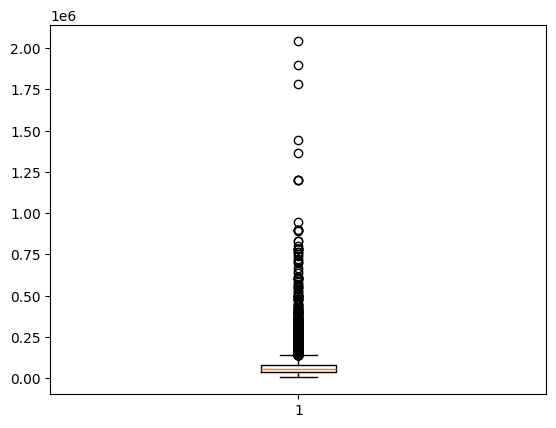

In [74]:
plt.boxplot(df["person_income"])

In [75]:
Q1 = df["person_income"].quantile(0.25)
Q3 = df["person_income"].quantile(0.75)

IQR = Q3-Q1

df = df[(df["person_income"] >= Q1 - 1.3 * IQR) & (df["person_income"] <= Q3 + 1.3 * IQR)]

{'whiskers': [<matplotlib.lines.Line2D at 0x254a3fa2960>,
 'caps': [<matplotlib.lines.Line2D at 0x254a3fa2f60>,
 'boxes': [<matplotlib.lines.Line2D at 0x254a3fa25d0>],
 'medians': [<matplotlib.lines.Line2D at 0x254a3fa3410>],
 'fliers': [<matplotlib.lines.Line2D at 0x254a3fa36e0>],
 'means': []}

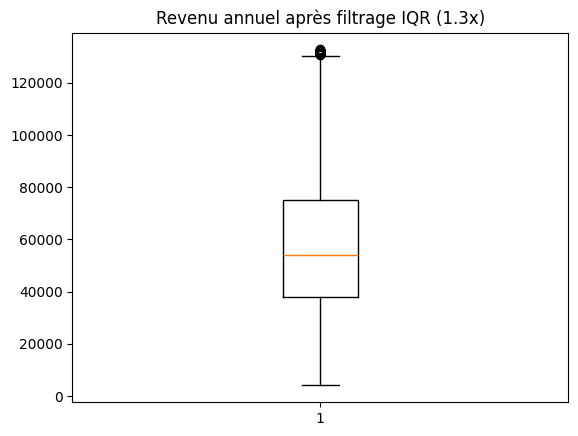

In [76]:
plt.title("Revenu annuel après filtrage IQR (1.3x)")
plt.boxplot(df["person_income"])

### Analyse des valeurs manquantes : 

In [77]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2879
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Trop de valeurs manquantes pour loan_status on va essayer de faire une imputation par variable corrélée (cf cours ML APP)

In [78]:
df.corr(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000,0.077,0.161,0.034,0.011,-0.016,-0.020,0.878
person_income,0.077,1.000,0.192,0.377,-0.044,-0.253,-0.324,0.055
person_emp_length,0.161,0.192,1.000,0.099,-0.065,-0.085,-0.044,0.139
loan_amnt,0.034,0.377,0.099,1.000,0.134,0.134,0.657,0.026
loan_int_rate,0.011,-0.044,-0.065,0.134,1.000,0.340,0.129,0.016
loan_status,-0.016,-0.253,-0.085,0.134,0.340,1.000,0.381,-0.011
loan_percent_income,-0.020,-0.324,-0.044,0.657,0.129,0.381,1.000,-0.012
cb_person_cred_hist_length,0.878,0.055,0.139,0.026,0.016,-0.011,-0.012,1.000


Le Random Forest (qu’il soit de régression ou de classification) est :
non linéaire → il n’a pas besoin que les variables soient corrélées ou transformées,
robuste aux échelles différentes (pas besoin de normaliser),
capable de gérer les interactions complexes entre variables,
et tolérant au bruit (il ne va pas surpondérer une variable inutile).

Si une variable n’est pas corrélée, le modèle ne l’utilisera presque pas dans ses arbres (poids faible).
Si une variable est fortement liée, elle apparaîtra souvent dans les splits → haute importance.

In [79]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [80]:
features = ['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
         'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length']

target = "loan_int_rate"

df_known = df[df[target].notna()]
df_missing = df[df[target].isna()]

X = df_known[features]
y = df_known[target]

X_enc = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# Variables
features = [
    'person_age', 'person_income', 'person_home_ownership',
    'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
    'loan_status', 'loan_percent_income',
    'cb_person_default_on_file', 'cb_person_cred_hist_length'
]
target = "loan_int_rate"

# Séparation entre valeurs connues et manquantes
df_known = df[df[target].notna()]
df_missing = df[df[target].isna()]

# Données d'entraînement
X = df_known[features]
y = df_known[target]

# Encodage des variables catégorielles
X_enc = pd.get_dummies(X, drop_first=True)

# Division en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42
)

# Modèle Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Prédictions sur le train et le test
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Évaluation sur le train
print("=== TRAIN SET ===")
print("MAE (train) :", mean_absolute_error(y_train, y_pred_train))
print("R² (train)  :", r2_score(y_train, y_pred_train))

# Évaluation sur le test
print("\n=== TEST SET ===")
print("MAE (test) :", mean_absolute_error(y_test, y_pred_test))
print("R² (test)  :", r2_score(y_test, y_pred_test))

# Importance des variables
importances = pd.Series(rf.feature_importances_, index=X_enc.columns)
print("\nImportance des variables :")
print(importances.sort_values(ascending=False).head(10))


=== TRAIN SET ===
MAE (train) : 0.2879160000942407
R² (train)  : 0.9866839932343152

=== TEST SET ===
MAE (test) : 0.7774326205244176
R² (test)  : 0.9052570084265184

Importance des variables :
cb_person_default_on_file_Y   0.253
loan_grade_C                  0.162
loan_grade_B                  0.154
loan_grade_D                  0.154
loan_grade_E                  0.120
loan_grade_F                  0.045
person_income                 0.021
loan_amnt                     0.016
loan_grade_G                  0.014
loan_percent_income           0.013
dtype: float64


In [82]:
if not df_missing.empty:
    X_missing = pd.get_dummies(df_missing[features], drop_first=True)
    X_missing = X_missing.reindex(columns=X_enc.columns, fill_value=0)
    preds = rf.predict(X_missing)
    df.loc[df[target].isna(), target] = preds
    print(f"\n{len(df_missing)} valeurs manquantes de '{target}' imputées avec Random Forest.")


2879 valeurs manquantes de 'loan_int_rate' imputées avec Random Forest.


In [83]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

### On regarde si y a des doublons : 

In [84]:
print(f"Le nombre de doublons est de : {df.duplicated().sum()}")

Le nombre de doublons est de : 150


In [85]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
2431,21,15600,RENT,0.000,MEDICAL,A,2800,7.400,1,0.180,N,4
17758,21,15600,RENT,0.000,MEDICAL,A,2800,7.400,1,0.180,N,4
2498,21,18000,RENT,0.000,DEBTCONSOLIDATION,A,3000,7.900,1,0.170,N,2
17601,21,18000,RENT,0.000,DEBTCONSOLIDATION,A,3000,7.900,1,0.170,N,2
1778,21,20000,RENT,0.000,MEDICAL,A,2000,7.267,0,0.100,N,3
...,...,...,...,...,...,...,...,...,...,...,...,...
32010,42,39996,MORTGAGE,2.000,HOMEIMPROVEMENT,A,2500,5.420,0,0.060,N,12
29484,43,11340,RENT,4.000,EDUCATION,C,1950,13.783,1,0.170,N,11
32279,43,11340,RENT,4.000,EDUCATION,C,1950,13.783,1,0.170,N,11
31676,49,120000,MORTGAGE,12.000,MEDICAL,B,12000,10.990,0,0.100,N,12


In [86]:
df = df.drop_duplicates()

In [87]:
print(f"Le nombre de doublons est de : {df.duplicated().sum()}")

Le nombre de doublons est de : 0


In [88]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,29731.000,29731.000,29731.000,29731.000,29731.000,29731.000,29731.000,29731.000
mean,27.581,58377.403,4.690,9304.350,11.031,0.223,0.175,5.724
std,6.100,26357.048,3.942,6005.985,3.204,0.416,0.107,4.005
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.010,2.000
25%,23.000,38004.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,54000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,75000.000,7.000,12000.000,13.470,0.000,0.230,8.000
max,70.000,132750.000,38.000,35000.000,23.220,1.000,0.830,30.000


Vérifions si y a des gens quiont taff + que ce qu'ils ont vécus

In [ ]:
(df["person_age"] < df["person_emp_length"]).sum()

np.int64(0)

### Enregistrons la base au format CSV

In [91]:
df.to_csv(path_or_buf = "../data/output/df_credit_clear.csv",
          sep = ",")

In [ ]:
df.columns